
# 매출은 성장하는데 왜 AOV는 오르지 않는가
### ▸ AOV 정체 원인 분석 및 전략 제안


## 0. 데이터 전처리
-----

### Import Packages

In [264]:
import pandas as pd
import numpy as np
from datetime import datetime

import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 모두다 나오게 출력
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

plt.rcParams['font.family'] = 'AppleGothic'
#plt.rcParams['font.family'] ='Malgun Gothic'   #window 용
plt.rcParams['axes.unicode_minus'] =False

### Load Tables


In [265]:

# 파일 로드
customer_raw = pd.read_csv('data/customer.csv')
product_raw = pd.read_csv('data/product.csv', on_bad_lines='skip')
transactions_raw = pd.read_csv('data/transactions.csv')
click_stream_raw = pd.read_csv('data/click_stream.csv')

customer = customer_raw.copy()
product = product_raw.copy()
transactions = transactions_raw.copy()
click_stream = click_stream_raw.copy()

### Explore Table


In [266]:
# Customer 테이블 기본 구조 확인
customer.info()
print(customer.shape)
print(customer.dtypes)
customer.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   customer_id         100000 non-null  int64  
 1   first_name          100000 non-null  str    
 2   last_name           100000 non-null  str    
 3   username            100000 non-null  str    
 4   email               100000 non-null  str    
 5   gender              100000 non-null  str    
 6   birthdate           100000 non-null  str    
 7   device_type         100000 non-null  str    
 8   device_id           100000 non-null  str    
 9   device_version      100000 non-null  str    
 10  home_location_lat   100000 non-null  float64
 11  home_location_long  100000 non-null  float64
 12  home_location       100000 non-null  str    
 13  home_country        100000 non-null  str    
 14  first_join_date     100000 non-null  str    
dtypes: float64(2), int64(1), str(12)
memory usage:

,customer_id,first_name,last_name,username,email,gender,birthdate,device_type,device_id,device_version,home_location_lat,home_location_long,home_location,home_country,first_join_date
0,2870,Lala,Maryati,671a0865-ac4e-4dc4-9c4f-c286a1176f7e,671a0865_ac4e_4dc4_9c4f_c286a1176f7e@startupca...,F,1996-06-14,iOS,c9c0de76-0a6c-4ac2-843f-65264ab9fe63,iPhone; CPU iPhone OS 14_2_1 like Mac OS X,-1,101,Sumatera Barat,Indonesia,2019-07-21
1,8193,Maimunah,Laksmiwati,83be2ba7-8133-48a4-bbcb-b46a2762473f,83be2ba7_8133_48a4_bbcb_b46a2762473f@zakyfound...,F,1993-08-16,Android,fb331c3d-f42e-40fe-afe2-b4b73a8a6e25,Android 2.2.1,-6,107,Jakarta Raya,Indonesia,2017-07-16
2,7279,Bakiman,Simanjuntak,3250e5a3-1d23-4675-a647-3281879d42be,3250e5a3_1d23_4675_a647_3281879d42be@startupca...,M,1989-01-23,iOS,d13dde0a-6ae1-43c3-83a7-11bbb922730b,iPad; CPU iPad OS 4_2_1 like Mac OS X,-9,116,Nusa Tenggara Barat,Indonesia,2020-08-23


In [267]:
# product 테이블 기본 구조 확인
product.info()
print(product.shape)
print(product.dtypes)
product.head(3)


<class 'pandas.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  str    
 2   masterCategory      44424 non-null  str    
 3   subCategory         44424 non-null  str    
 4   articleType         44424 non-null  str    
 5   baseColour          44409 non-null  str    
 6   season              44403 non-null  str    
 7   year                44423 non-null  float64
 8   usage               44107 non-null  str    
 9   productDisplayName  44417 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 3.4 MB
(44424, 10)
id                      int64
gender                    str
masterCategory            str
subCategory               str
articleType               str
baseColour                str
season                    str
year                  float64
usag

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016,Casual,Titan Women Silver Watch


In [268]:
# transactions 테이블 기본 구조 확인
transactions.info()
print(transactions.shape)
print(transactions.dtypes)
transactions.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 852584 entries, 0 to 852583
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   created_at              852584 non-null  str    
 1   customer_id             852584 non-null  int64  
 2   booking_id              852584 non-null  str    
 3   session_id              852584 non-null  str    
 4   product_metadata        852584 non-null  str    
 5   payment_method          852584 non-null  str    
 6   payment_status          852584 non-null  str    
 7   promo_amount            852584 non-null  int64  
 8   promo_code              326536 non-null  str    
 9   shipment_fee            852584 non-null  int64  
 10  shipment_date_limit     852584 non-null  str    
 11  shipment_location_lat   852584 non-null  float64
 12  shipment_location_long  852584 non-null  float64
 13  total_amount            852584 non-null  int64  
dtypes: float64(2), int64(4), str(8)

,created_at,customer_id,booking_id,session_id,product_metadata,payment_method,payment_status,promo_amount,promo_code,shipment_fee,shipment_date_limit,shipment_location_lat,shipment_location_long,total_amount
0,2018-07-29T15:22:01.458193Z,5868,186e2bee-0637-4710-8981-50c2d737bc42,3abaa6ce-e320-4e51-9469-d9f3fa328e86,"[{'product_id': 54728, 'quantity': 1, 'item_pr...",Debit Card,Success,1415,WEEKENDSERU,10000,2018-08-03T05:07:24.812676Z,-8,112,199832
1,2018-07-30T12:40:22.365620Z,4774,caadb57b-e808-4f94-9e96-8a7d4c9898db,2ee5ead1-f13e-4759-92df-7ff48475e970,"[{'product_id': 16193, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,10000,2018-08-03T01:29:03.415705Z,3,108,155526
2,2018-09-15T11:51:17.365620Z,4774,6000fffb-9c1a-4f4a-9296-bc8f6b622b50,93325fb6-eb00-4268-bb0e-6471795a0ad0,"[{'product_id': 53686, 'quantity': 4, 'item_pr...",OVO,Success,0,NaN,10000,2018-09-18T08:41:49.422380Z,-3,116,550696


In [269]:
# click_stream 테이블 기본 구조 확인
click_stream.info(show_counts=True)
print(click_stream.shape)
print(click_stream.dtypes)
click_stream.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 12833602 entries, 0 to 12833601
Data columns (total 6 columns):
 #   Column          Non-Null Count     Dtype
---  ------          --------------     -----
 0   session_id      12833602 non-null  str  
 1   event_name      12833602 non-null  str  
 2   event_time      12833602 non-null  str  
 3   event_id        12833602 non-null  str  
 4   traffic_source  12833602 non-null  str  
 5   event_metadata  4289540 non-null   str  
dtypes: str(6)
memory usage: 587.5 MB
(12833602, 6)
session_id        str
event_name        str
event_time        str
event_id          str
traffic_source    str
event_metadata    str
dtype: object


,session_id,event_name,event_time,event_id,traffic_source,event_metadata
0,fb0abf9e-fd1a-44dd-b5c0-2834d5a4b81c,HOMEPAGE,2019-09-06T15:54:32.821085Z,9c4388c4-c95b-4678-b5ca-e9cbc0734109,MOBILE,NaN
1,fb0abf9e-fd1a-44dd-b5c0-2834d5a4b81c,SCROLL,2019-09-06T16:03:57.821085Z,4690e1f5-3f99-42d3-84a5-22c4c4d8500a,MOBILE,NaN
2,7d440441-e67a-4d36-b324-80ffd636d166,HOMEPAGE,2019-09-01T12:05:10.322763Z,88aeaeb5-ec98-4859-852c-8abb483faf31,MOBILE,NaN


### Preprocessing 


+ #### 날짜 타입 변경

In [270]:
# 날짜 Type 변경
customer['birthdate'] = pd.to_datetime(customer['birthdate'], errors='coerce')
transactions['created_at'] = pd.to_datetime(transactions['created_at'], errors='coerce')
transactions['shipment_date_limit'] = pd.to_datetime(transactions['shipment_date_limit'], errors='coerce')
click_stream['event_time'] = pd.to_datetime(click_stream['event_time'], errors='coerce')

In [271]:
customer.info()
transactions.info()
click_stream.info()
transactions.head()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   customer_id         100000 non-null  int64         
 1   first_name          100000 non-null  str           
 2   last_name           100000 non-null  str           
 3   username            100000 non-null  str           
 4   email               100000 non-null  str           
 5   gender              100000 non-null  str           
 6   birthdate           100000 non-null  datetime64[us]
 7   device_type         100000 non-null  str           
 8   device_id           100000 non-null  str           
 9   device_version      100000 non-null  str           
 10  home_location_lat   100000 non-null  float64       
 11  home_location_long  100000 non-null  float64       
 12  home_location       100000 non-null  str           
 13  home_country        100000 non-null  str 

,created_at,customer_id,booking_id,session_id,product_metadata,payment_method,payment_status,promo_amount,promo_code,shipment_fee,shipment_date_limit,shipment_location_lat,shipment_location_long,total_amount
0,2018-07-29 15:22:01.458193+00:00,5868,186e2bee-0637-4710-8981-50c2d737bc42,3abaa6ce-e320-4e51-9469-d9f3fa328e86,"[{'product_id': 54728, 'quantity': 1, 'item_pr...",Debit Card,Success,1415,WEEKENDSERU,10000,2018-08-03 05:07:24.812676+00:00,-8,112,199832
1,2018-07-30 12:40:22.365620+00:00,4774,caadb57b-e808-4f94-9e96-8a7d4c9898db,2ee5ead1-f13e-4759-92df-7ff48475e970,"[{'product_id': 16193, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,10000,2018-08-03 01:29:03.415705+00:00,3,108,155526
2,2018-09-15 11:51:17.365620+00:00,4774,6000fffb-9c1a-4f4a-9296-bc8f6b622b50,93325fb6-eb00-4268-bb0e-6471795a0ad0,"[{'product_id': 53686, 'quantity': 4, 'item_pr...",OVO,Success,0,NaN,10000,2018-09-18 08:41:49.422380+00:00,-3,116,550696
3,2018-11-01 11:23:48.365620+00:00,4774,f5e530a7-4350-4cd1-a3bc-525b5037bcab,bcad5a61-1b67-448d-8ff4-781d67bc56e4,"[{'product_id': 20228, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,0,2018-11-05 17:42:27.954235+00:00,-4,120,271012
4,2018-12-18 11:20:30.365620+00:00,4774,0efc0594-dbbf-4f9a-b0b0-a488cfddf8a2,df1042ab-13e6-4072-b9d2-64a81974c51a,"[{'product_id': 55220, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,0,2018-12-23 17:24:07.361785+00:00,-4,120,198753


+ #### 최근 동향을 파악하기 위해 4개년치 추출

In [272]:
# 4개년 계산
max_year = pd.to_datetime(transactions['created_at']).max().year  #2021
years = [max_year - i for i in range(4)]
start_year = min(years)

# 각 연도별 필터링
transactions = transactions[transactions['created_at'].dt.year >= start_year]
click_stream = click_stream[click_stream['event_time'].dt.year >= start_year]


In [273]:
# 결과 요약 출력
print("기준 연도:", years)
print("거래 수:", len(transactions))
print("클릭 로그 수:", len(click_stream))
print(transactions['created_at'].min())
print(click_stream ['event_time'].min())

기준 연도: [2022, 2021, 2020, 2019]
거래 수: 740513
클릭 로그 수: 11126385
2019-01-01 00:04:56.716253+00:00
2019-01-01 00:00:01.231240+00:00


+ #### 결측치 처리

In [274]:
#결측치 처리
transactions['promo_amount'] = transactions['promo_amount'].fillna(0)
transactions['promo_code'] = transactions['promo_code'].fillna('None')
click_stream['traffic_source'] = click_stream['traffic_source'].fillna('Unknown')

In [275]:
transactions.info()
click_stream.info(show_counts=True)

<class 'pandas.DataFrame'>
Index: 740513 entries, 5 to 852583
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   created_at              740513 non-null  datetime64[us, UTC]
 1   customer_id             740513 non-null  int64              
 2   booking_id              740513 non-null  str                
 3   session_id              740513 non-null  str                
 4   product_metadata        740513 non-null  str                
 5   payment_method          740513 non-null  str                
 6   payment_status          740513 non-null  str                
 7   promo_amount            740513 non-null  int64              
 8   promo_code              740513 non-null  str                
 9   shipment_fee            740513 non-null  int64              
 10  shipment_date_limit     740513 non-null  datetime64[us, UTC]
 11  shipment_location_lat   740513 non-null  f

+ #### 이상치처리
    결제 주체 신뢰성 확보를 위해 **만 10세 미만 데이터는 입력 오류로 판단**  
    분석 모수에서 제외

In [276]:
#이상치 처리
#나이 이상치 확인
customer['age'] = 2021 - customer['birthdate'].dt.year  #거래 기준 max날짜 기준
#display(customer)
print(customer['age'].max())
print(customer['age'].min())    #5 ->10
customer.loc[(customer['age'] < 10)] = np.nan
customer['age'].count()


67
5


np.int64(99794)

+ #### 필요컬럼 추가 ####
    1. Customer
        - 연령대그룹 : age_groups
    2. Transactions
        - 프로모션 사용 여부 :  promo_used
        - 거래 성공 여부 : is_success
        - 실제거래 금액 : net_amount

In [277]:
# Customer
bins = [0, 20, 30, 40, 50, 60, 200]
labels = ['10대', '20대', '30대', '40대', '50대', '60대+']
customer['age_group'] = pd.cut(
    customer['age'], bins=bins, labels=labels, right=False
)

In [278]:
# Transactions
transactions['promo_used'] = (transactions['promo_code'].str.lower() != 'none') | (transactions['promo_amount'] > 0)
transactions['is_success'] = (transactions['payment_status'] == 'Success').astype(int)
transactions['net_amount'] = transactions['total_amount'] - transactions['shipment_fee']

In [279]:
#customer.head()
transactions.head()

,created_at,customer_id,booking_id,session_id,product_metadata,payment_method,payment_status,promo_amount,promo_code,shipment_fee,shipment_date_limit,shipment_location_lat,shipment_location_long,total_amount,promo_used,is_success,net_amount
5,2019-02-03 11:25:55.365620+00:00,4774,1ed58c46-67fb-4386-924b-983c74ccb4d7,7fa0b583-6d30-40bc-8b61-0f70f5bef30f,"[{'product_id': 59620, 'quantity': 1, 'item_pr...",Debit Card,Success,6369,WEEKENDMANTAP,5000,2019-02-07 10:41:59.997463+00:00,-4,120,181865,True,1,176865
6,2019-03-22 11:53:02.365620+00:00,4774,c0ced313-e6b1-4a2a-b21f-347eccda5f96,e140f1f1-6da1-42b3-b2d1-56ac6fc72d4a,"[{'product_id': 53136, 'quantity': 1, 'item_pr...",Credit Card,Success,0,None,10000,2019-03-27 14:40:13.181562+00:00,-8,111,306599,False,1,296599
7,2019-05-08 11:29:21.365620+00:00,4774,0ed6730f-a5db-4e40-9a54-c343474d872c,e7eff973-b499-4b8d-9892-89e67e5fd7d4,"[{'product_id': 14142, 'quantity': 1, 'item_pr...",Credit Card,Success,0,None,10000,2019-05-10 20:09:58.104955+00:00,3,99,153913,False,1,143913
8,2019-06-24 12:08:52.365620+00:00,4774,6edd9366-4788-4bbb-ae5b-744e45e6118d,0d20c278-e082-4f28-9afe-8b5907d7a284,"[{'product_id': 12282, 'quantity': 1, 'item_pr...",Credit Card,Success,4019,AZ2022,10000,2019-06-28 10:34:36.588498+00:00,-6,107,370757,True,1,360757
9,2019-08-10 12:14:24.365620+00:00,4774,771665e9-7df2-41c8-8168-16d5cdd407a1,f5352cdc-0e3c-4e77-af42-645501dcded4,"[{'product_id': 53051, 'quantity': 1, 'item_pr...",Credit Card,Success,9072,WEEKENDSERU,10000,2019-08-14 18:07:04.125993+00:00,-1,114,1295740,True,1,1285740


## 1. 비즈니스 문제 정의
-----

1) 월별 매출 추이 확인하기 

In [ ]:
# 연-월 컬럼 추가 (예: 2023-11)
transactions['year_month'] = transactions['created_at'].dt.tz_localize(None).dt.to_period('M')

# 연월별 거래량과 매출 합계 집계
monthly_stats = (transactions.groupby('year_month').agg(
    order_cnt = ('created_at', 'count'),  # 거래 건수
    gross_revenue = ('total_amount', 'sum'),       # 총매출 합계
    net_revenue = ('net_amount', 'sum')       # 총매출 합계
    ).reset_index()
)
monthly_stats['aov'] = monthly_stats['gross_revenue']/monthly_stats['order_cnt']
monthly_stats['aov_net'] = monthly_stats['net_revenue']/monthly_stats['order_cnt']

# 결과 확인
#display(monthly_stats)

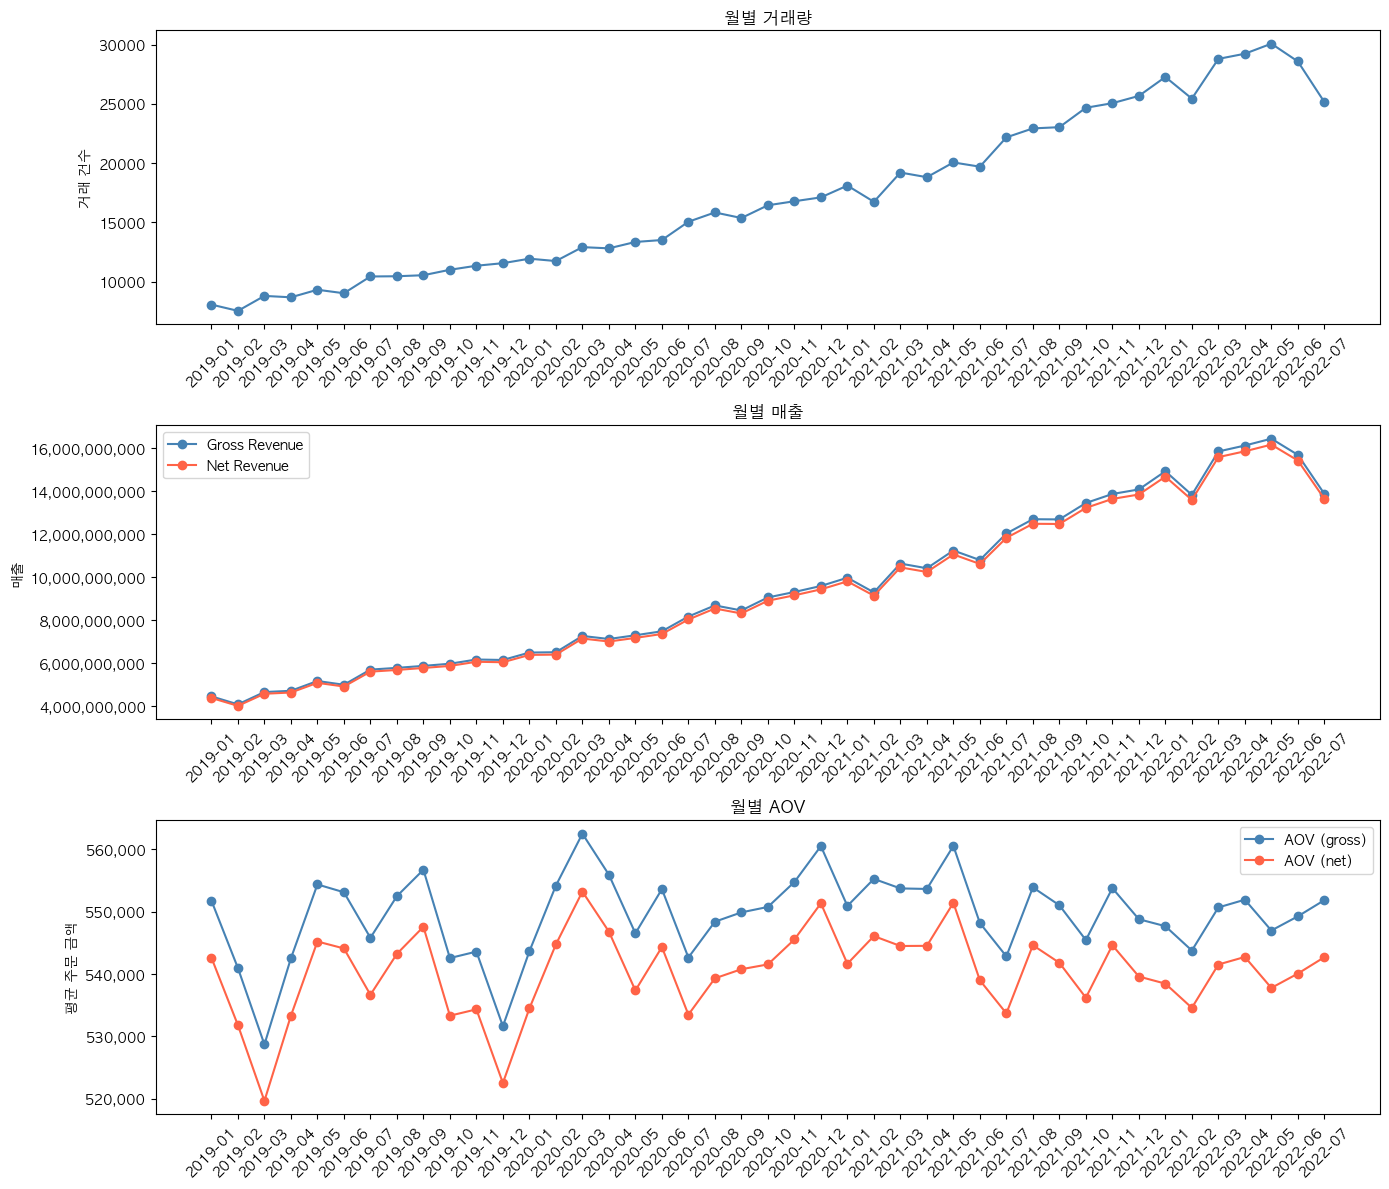

In [281]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
x = monthly_stats['year_month'].astype(str)

# 1. 월별 거래량
axes[0].plot(x, monthly_stats['order_cnt'], marker='o', color='steelblue')
axes[0].set_title('월별 거래량')
axes[0].set_ylabel('거래 건수')
axes[0].tick_params(axis='x', rotation=45)

# 2. 월별 매출 (gross vs net)
axes[1].plot(x, monthly_stats['gross_revenue'], marker='o', label='Gross Revenue', color='steelblue')
axes[1].plot(x, monthly_stats['net_revenue'],   marker='o', label='Net Revenue',   color='tomato')
axes[1].set_title('월별 매출')
axes[1].set_ylabel('매출')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# 3. AOV 추이
axes[2].plot(x, monthly_stats['aov'],     marker='o', label='AOV (gross)', color='steelblue')
axes[2].plot(x, monthly_stats['aov_net'], marker='o', label='AOV (net)',   color='tomato')
axes[2].set_title('월별 AOV')
axes[2].set_ylabel('평균 주문 금액')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
axes[2].legend()
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- 거래건수, 매출 : 2019년 이후 꾸준히 3배 이상 상승    
- AOV : 550,000원 내외에서 등락을 반복하며 **정체**

    ⇒ 매출 성장이 거래건수 증가에만 의존하고 있음  
    >   **AOV 정체의 원인 파악이 필요**

## 2. 가설 검증
-----

- ###  AOV 정체의 원인을 3가지 가설로 구조화

    | 가설 | 내용 | 핵심 질문 |
    |------|------|---------|
    | A. 신규고객 증가 | 신규고객이 늘면서 AOV 평균을 끌어내림 | 신규 vs 재구매 고객의 AOV 차이가 있는가? |
    | B. 프로모션 구조 문제 | 프로모션 의존도가 높아져 AOV 희석 | 프로모션 사용 시 AOV가 낮아지는가? |
    | C. 고가 세그먼트 이탈 | 고가 상품 구매층이 이탈하고 있음 | 고가 상품 구매 비율 감소하고 있는가? |

### A. 신규고객 증가로 AOV 평균이 낮아지는가?  
>        거래건수는 계속 오르는데 AOV는 정체  
>         → 새로운 고객이 계속 유입되고 있다는 신호  
>         → 신규고객은 보통 첫 구매라 소액 또는 탐색 구매를 하는 경향이 있음  
>         → 이게 AOV 평균을 끌어내릴 수 있다  

#### ⇒ 신규 vs 재구매 고객의 AOV 차이 비교

In [285]:
# 신규 고객 구분
# 1번 → 신규
# 2번 이상 → 재구매
transactions = transactions.sort_values('created_at')
transactions['purchase_rank'] = transactions.groupby('customer_id').cumcount() + 1
transactions['is_new'] = transactions['purchase_rank'] == 1

print(transactions['is_new'].value_counts())


is_new
False    692518
True      47995
Name: count, dtype: int64


In [286]:
# 연월별 거래량과 매출 합계 집계
monthly_segment = (transactions.groupby(['year_month', 'is_new']).agg(
    order_cnt = ('created_at', 'count'),  # 거래 건수
    gross_revenue = ('total_amount', 'sum'),       # 총매출 합계
    net_revenue = ('net_amount', 'sum'),       # 총매출 합계
    aov_mean=('total_amount', 'mean'),
    aov_median=('total_amount', 'median')
    ).reset_index()
)

monthly_segment['customer_type'] = monthly_segment['is_new'].map(
    {True: '신규', False: '재구매'}
)

# 결과 확인
display(monthly_segment)

,year_month,is_new,order_cnt,gross_revenue,net_revenue,aov_mean,aov_median,customer_type
0,2019-01,False,2199,1236476370,1216121370,562290,310125,재구매
1,2019-01,True,5868,3214743821,3161238821,547843,304550,신규
2,2019-02,False,4923,2677239299,2631979299,543823,301780,재구매
3,2019-02,True,2616,1401096258,1377241258,535587,302552,신규
4,2019-03,False,6826,3619917297,3557752297,530313,296402,재구매
5,2019-03,True,1974,1032616018,1015146018,523108,293060,신규
6,2019-04,False,7266,3951287435,3884377435,543805,304387,재구매
7,2019-04,True,1417,759461600,746336600,535964,302187,신규
8,2019-05,False,8046,4481618976,4408108976,557000,301945,재구매
9,2019-05,True,1274,685191562,673326562,537827,290744,신규


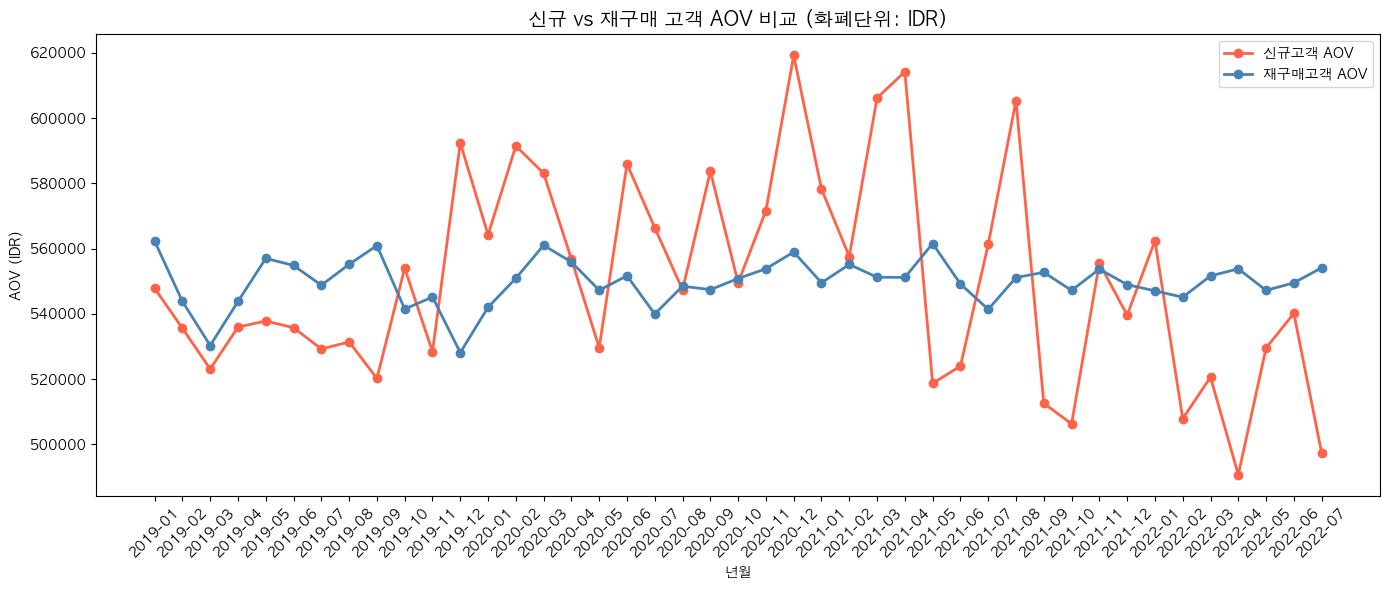

In [287]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# ── 차트 1 : 신규 vs 재구매 AOV (라인) ──────────────────
new_data = monthly_segment[monthly_segment['customer_type'] == '신규']
returning_data = monthly_segment[monthly_segment['customer_type'] == '재구매']

axes.plot(new_data['year_month'].astype(str), new_data['aov_mean'], marker='o', color="tomato", label='신규고객 AOV', linewidth=2)
axes.plot(returning_data['year_month'].astype(str), returning_data['aov_mean'], marker='o', color='steelblue', label='재구매고객 AOV', linewidth=2)

axes.set_title('신규 vs 재구매 고객 AOV 비교 (화폐단위: IDR)', fontsize=14)
axes.set_xlabel('년월')
axes.set_ylabel('AOV (IDR)')
axes.legend()

axes.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

##### 신규고객 AOV 등락이 심하다  
1. 신규고객이 프로모션에 반응해서 구매하는 건 아닐까?  
>    - 예상 시나리오 :
>       - 프로모션 있을 때 신규유입 → AOV 낮아짐  
>       - 프로모션 없을 때 신규유입 → AOV 높아짐  
  
2. 신규고객은 증가 하는가?  

In [288]:
# 신규/재구매 고객의 프로모션 사용 여부
promo_segment = transactions.groupby(['is_new', 'promo_used']).agg(
    order_count=('created_at', 'count'),
    aov_mean=('total_amount', 'mean'),
    gross_revenue=('total_amount', 'sum')
).reset_index()

# 고객 타입별 전체 건수
total_by_type = transactions.groupby('is_new')['created_at'].count().reset_index()
total_by_type.columns = ['is_new', 'total_count']

promo_segment = promo_segment.merge(total_by_type, on='is_new')
#print(total_by_type)
#print(promo_segment)

promo_segment['promo_ratio'] = (
    promo_segment['order_count'] / promo_segment['total_count'] * 100
).round(2)

promo_segment['customer_type'] = promo_segment['is_new'].map(
    {True: '신규', False: '재구매'}
)
promo_segment['promo_type'] = promo_segment['promo_used'].map(
    {True: '사용', False: '미사용'}
)

print(promo_segment[['customer_type', 'promo_type', 'order_count', 'total_count', 'promo_ratio', 'aov_mean']])

  customer_type promo_type  order_count  total_count  promo_ratio  aov_mean
0           재구매        미사용       432931       692518           63    552195
1           재구매         사용       259587       692518           37    546394
2            신규        미사용        30954        47995           64    549387
3            신규         사용        17041        47995           36    545323


In [289]:
# 신규고객 비율이 증가하고 있는가?
monthly_new_ratio = transactions.groupby('year_month').agg(
    total=('created_at', 'count'),
    new=('is_new', 'sum')
).reset_index()
monthly_new_ratio['new_ratio'] = (monthly_new_ratio['new'] / monthly_new_ratio['total'] * 100).round(2)

#print(monthly_new_ratio)

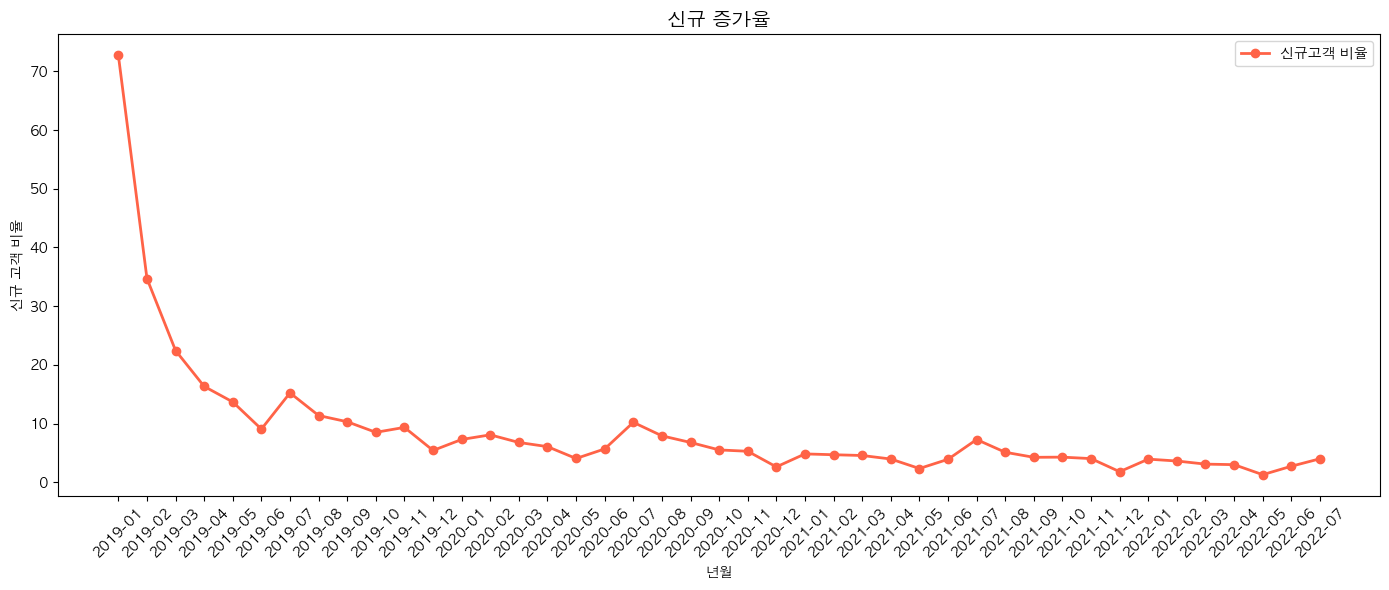

In [290]:
fig, axe = plt.subplots(1, 1, figsize=(14, 6))

# ── 차트 1 : 신규 vs 재구매 AOV (라인) ──────────────────

axe.plot(monthly_new_ratio['year_month'].astype(str), monthly_new_ratio['new_ratio'], marker='o', color="tomato", label='신규고객 비율', linewidth=2)


axe.set_title('신규 증가율', fontsize=14)
axe.set_xlabel('년월')
axe.set_ylabel('신규 고객 비율')
axe.legend()

axe.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

1. 신규고객이 프로모션에 반응해서 구매하는 건 아닐까?  
>    - 신규 / 재구매 고객의 프로모션 사용비율이 비슷하다.
>    - AOV가 프로모션 여부와 상관없이 비슷하다.
  
2. 신규고객은 증가 하는가?  
>    - 오히려 줄고 있다. 

##### ⇒ 재구매 고객은 늘고 있는데 왜 AOV 안 오르는지..

1. 재구매 횟수가 늘수록 AOV가 높아지는가?  
    - 오래된 고객일수록 더 많이 쓰는가?

2. 재구매 고객의 리텐션은 유지되고 있는가?  
    - 재구매는 하는데 구매 주기가 길어지는 건 아닌가?

In [291]:
# 재구매별 AOV
purchase_rank_aov = transactions.groupby('purchase_rank').agg(
    order_count=('created_at', 'count'),
    aov_mean=('total_amount', 'mean')
).reset_index()

# 구매 20회까지만 보기 (구매수가 많을수록 고객수가 줄어듦)
purchase_rank_aov = purchase_rank_aov[purchase_rank_aov['purchase_rank'] <= 20]

print(purchase_rank_aov)

    purchase_rank  order_count  aov_mean
0               1        47995    547944
1               2        38810    551400
2               3        33601    546604
3               4        30000    554753
4               5        27285    546941
5               6        24965    549204
6               7        23012    548207
7               8        21335    547717
8               9        19871    549995
9              10        18608    554898
10             11        17483    549749
11             12        16495    565378
12             13        15597    539340
13             14        14777    564302
14             15        13974    553950
15             16        13290    548706
16             17        12662    556708
17             18        12077    547597
18             19        11511    557477
19             20        10957    555686


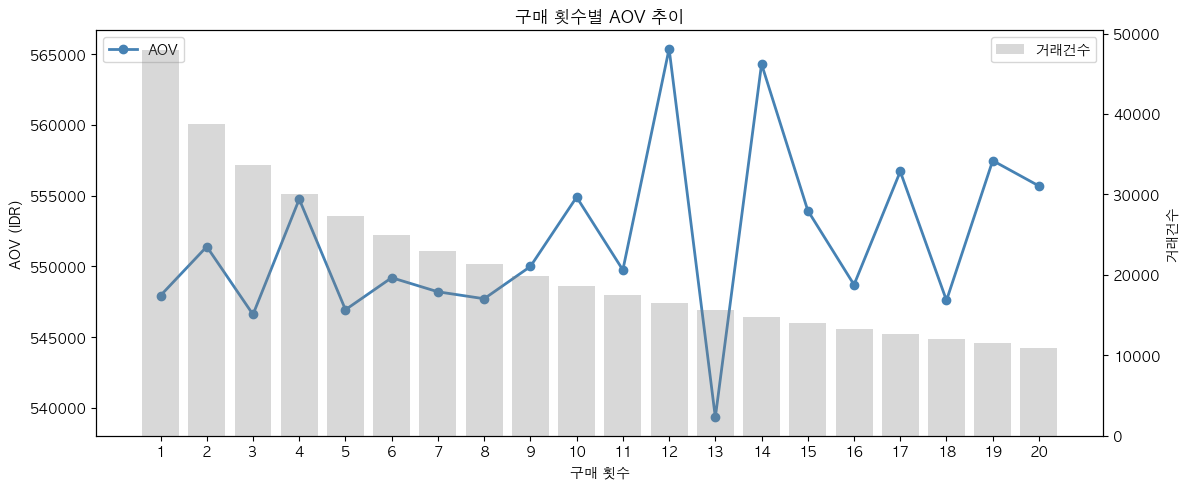

In [322]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# AOV 라인
ax1.plot(purchase_rank_aov['purchase_rank'],
         purchase_rank_aov['aov_mean'],
         marker='o', color='steelblue', linewidth=2, label='AOV')
ax1.set_xlabel('구매 횟수')
ax1.set_ylabel('AOV (IDR)')
ax1.set_title('구매 횟수별 AOV 추이')


# 거래건수 막대 (보조축)
ax2 = ax1.twinx()
ax2.bar(purchase_rank_aov['purchase_rank'],
        purchase_rank_aov['order_count'],
        alpha=0.3, color='gray', label='거래건수')
ax2.set_ylabel('거래건수')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

ax1.set_xticks(range(1, 21))
ax1.set_xticklabels(range(1, 21))

plt.tight_layout()
plt.show()

In [323]:
# 고객별 첫 구매 월 (코호트 기준)
customer_cohort = transactions.groupby('customer_id')['created_at'].min().reset_index()
customer_cohort.columns = ['customer_id', 'cohort_date']
customer_cohort['cohort_month'] = customer_cohort['cohort_date'].dt.to_period('M')

# 트랜잭션에 코호트 월 붙이기
transactions = transactions.merge(customer_cohort[['customer_id', 'cohort_month']], 
                                   on='customer_id', how='left')

# 구매 월
transactions['purchase_month'] = transactions['created_at'].dt.to_period('M')

# 코호트 기준 몇 번째 달인지
transactions['period_number'] = (
    transactions['purchase_month'] - transactions['cohort_month']
).apply(lambda x: x.n)

# 리텐션 테이블 생성
cohort_data = transactions.groupby(['cohort_month', 'period_number'])['customer_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot_table(index='cohort_month', 
                                        columns='period_number', 
                                        values='customer_id')

# 리텐션 비율
cohort_size = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100
retention = retention.round(2)

/var/folders/s8/ydysgqf95zvfb85flggqqzlw0000gn/T/ipykernel_25031/616513150.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  customer_cohort['cohort_month'] = customer_cohort['cohort_date'].dt.to_period('M')
/var/folders/s8/ydysgqf95zvfb85flggqqzlw0000gn/T/ipykernel_25031/616513150.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  transactions['purchase_month'] = transactions['created_at'].dt.to_period('M')


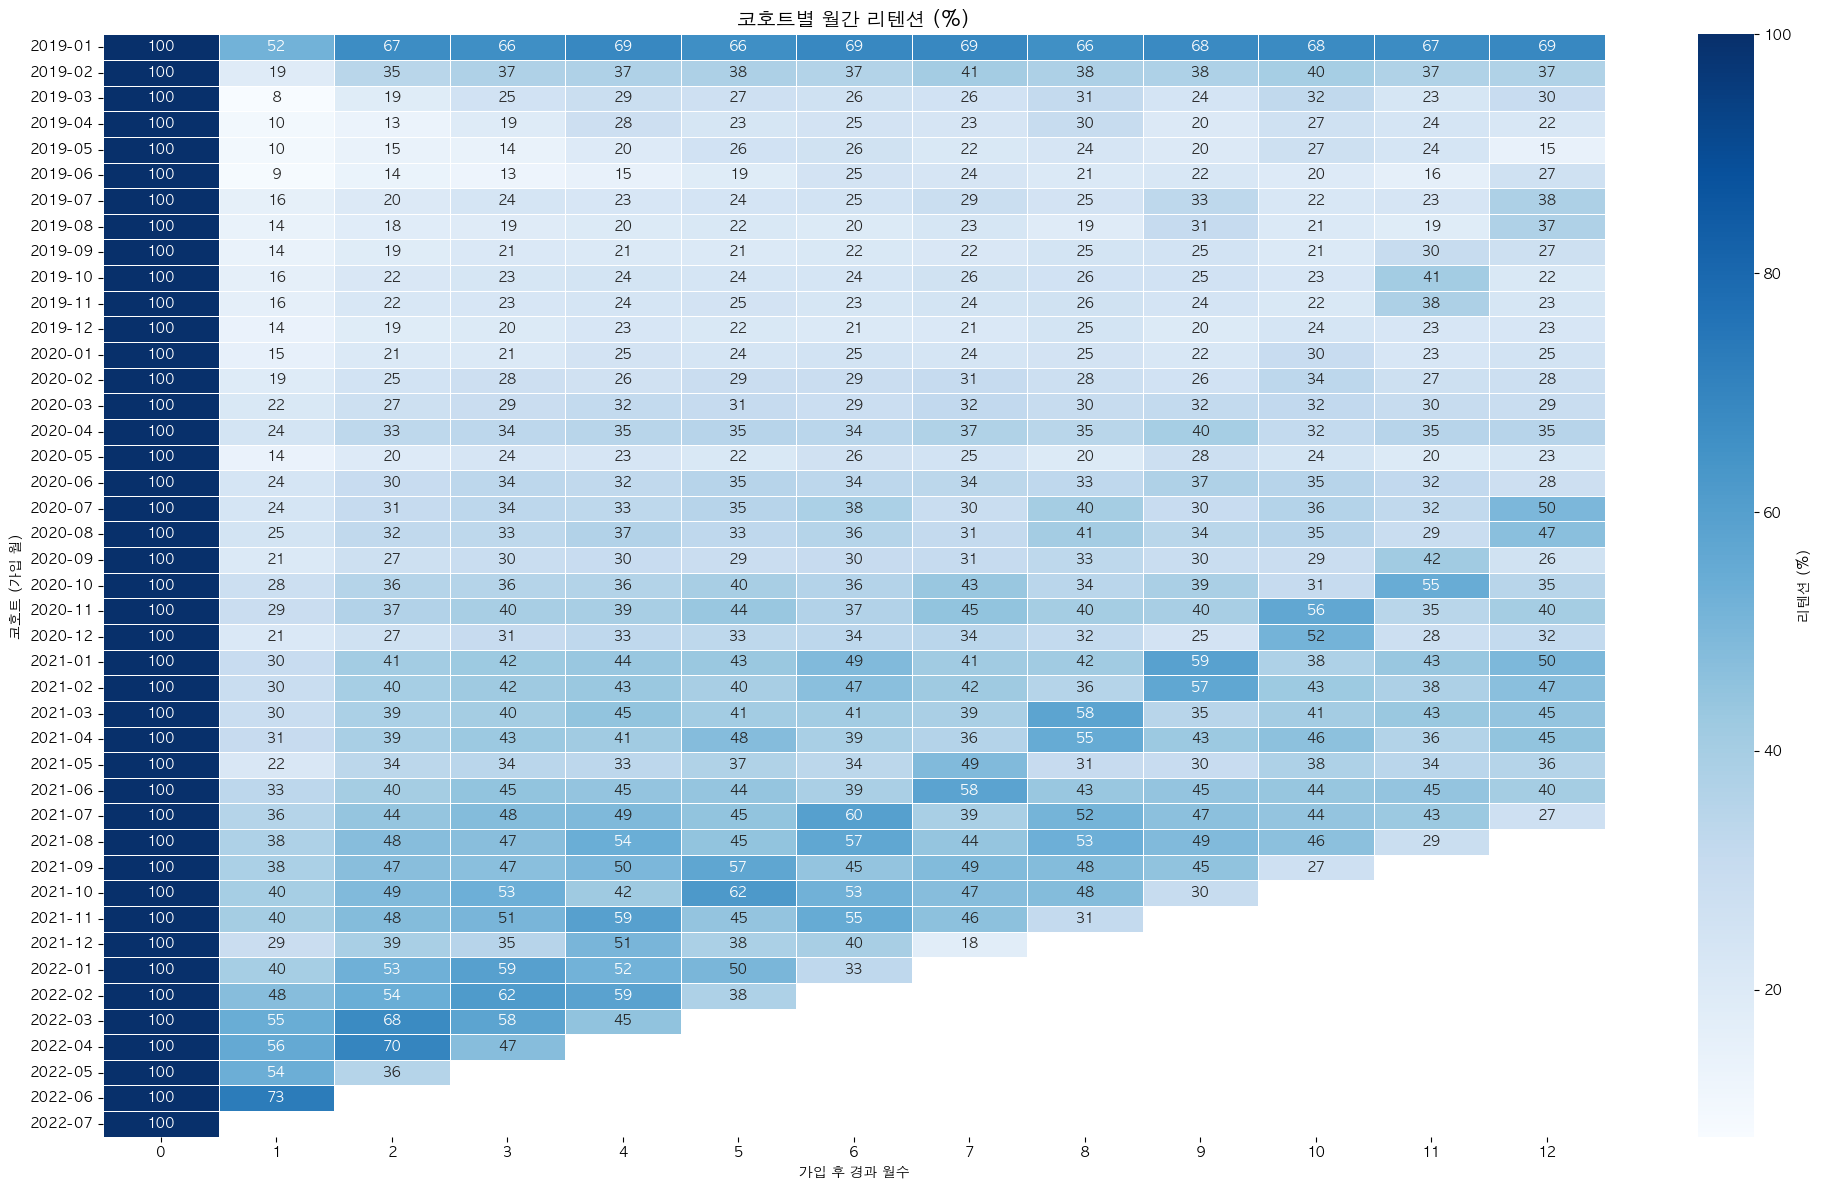

In [294]:
plt.figure(figsize=(20, 12))
sns.heatmap(retention.iloc[:, :13],  # 12개월까지만
            annot=True, fmt='.0f',
            cmap='Blues',
            linewidths=0.5,
            cbar_kws={'label': '리텐션 (%)'}
            )

plt.title('코호트별 월간 리텐션 (%)', fontsize=14)
plt.xlabel('가입 후 경과 월수')
plt.ylabel('코호트 (가입 월)')
plt.tight_layout()
plt.show()

In [295]:
# 코호트별 AOV 히트맵
cohort_aov = transactions.groupby(
    ['cohort_month', 'period_number'])['total_amount'].mean().reset_index()

cohort_aov_pivot = cohort_aov.pivot_table(
    index='cohort_month',
    columns='period_number',
    values='total_amount'
).round(0)

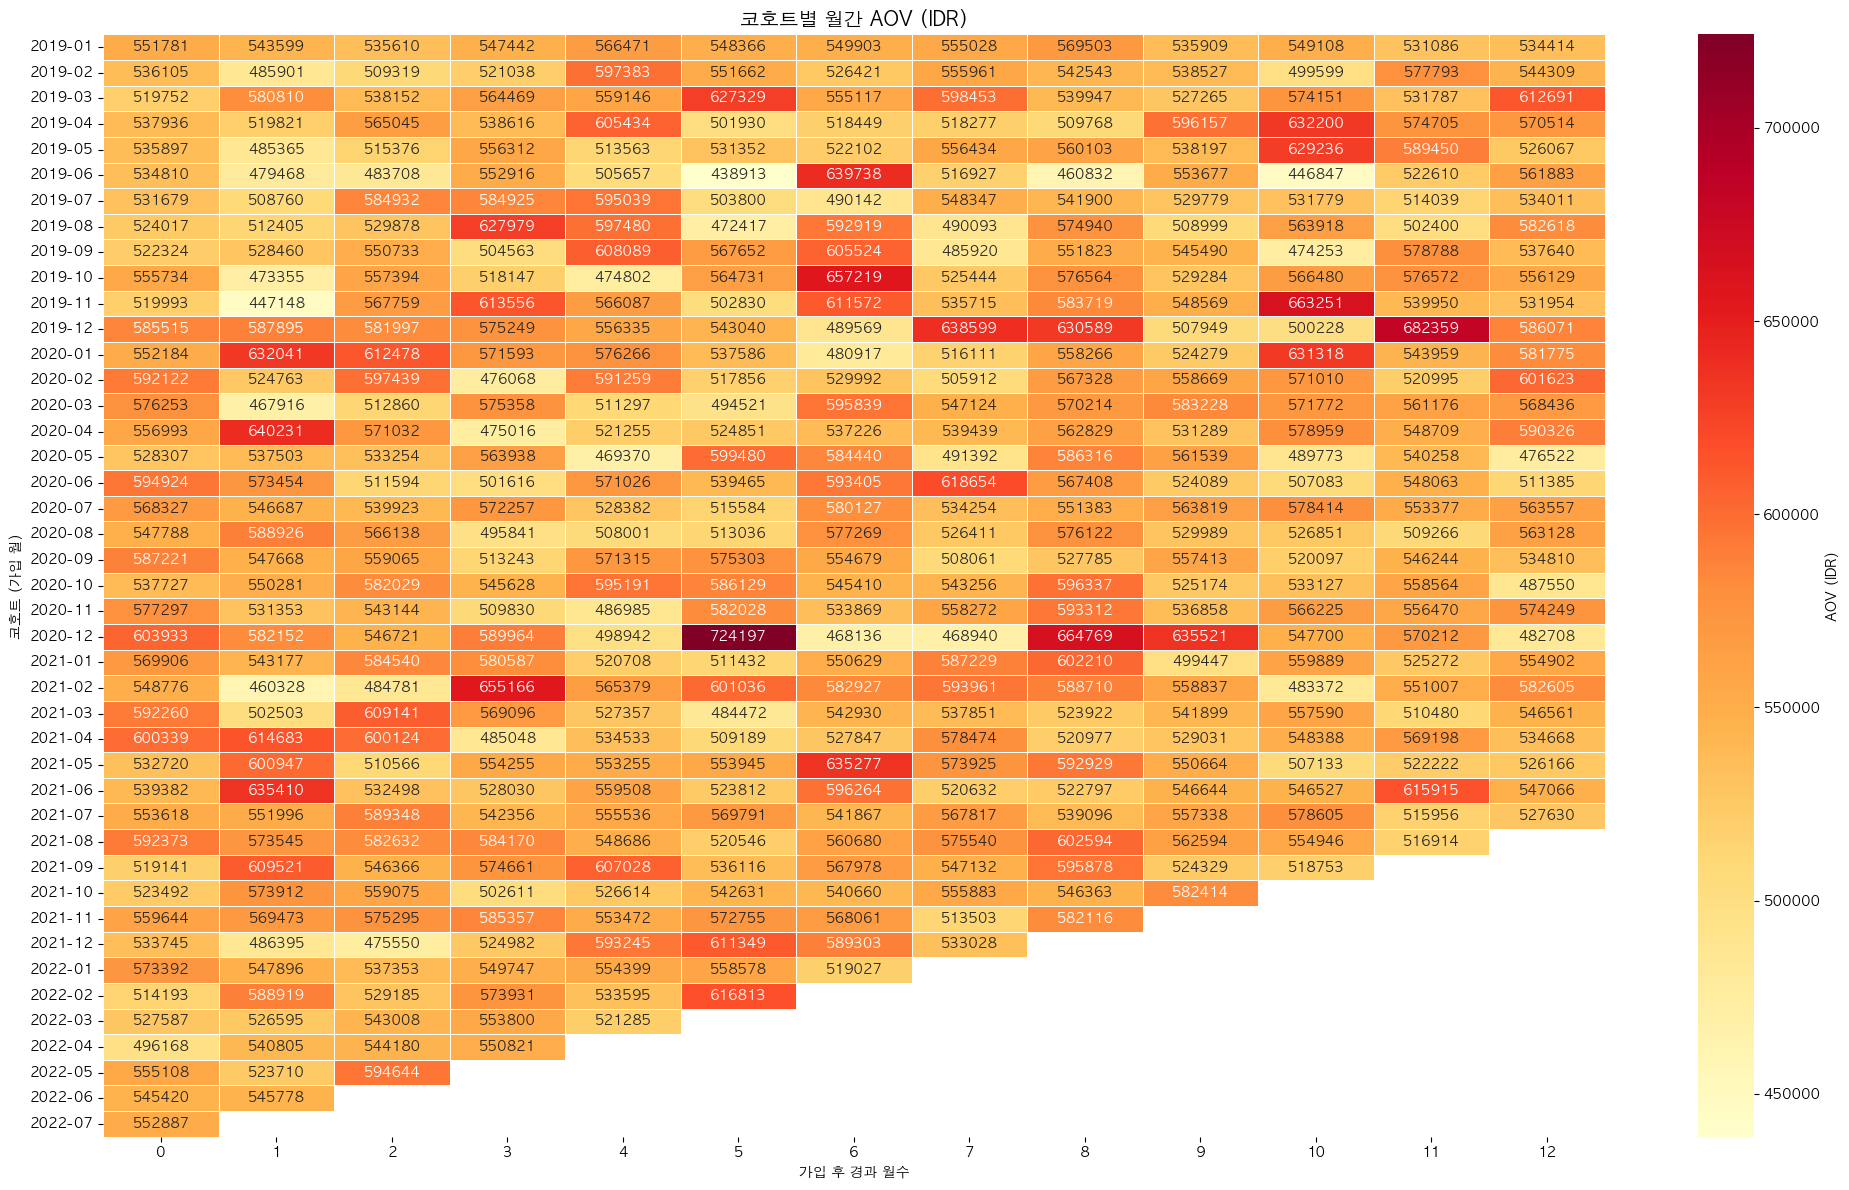

In [296]:
plt.figure(figsize=(20, 12))
sns.heatmap(cohort_aov_pivot.iloc[:, :13],
            annot=True, fmt='.0f',
            cmap='YlOrRd',
            linewidths=0.5,
            cbar_kws={'label': 'AOV (IDR)'}
            )

plt.title('코호트별 월간 AOV (IDR)', fontsize=14)
plt.xlabel('가입 후 경과 월수')
plt.ylabel('코호트 (가입 월)')
plt.tight_layout()
plt.show()


### 가설 A 결론
**"신규고객 증가로 AOV 평균이 낮아지는가?"**

#### 분석 결과

1. 신규고객 비율
   - 2019년 초 72%에서 2022년 1~3%로 감소  
   - **신규고객 증가는 AOV 정체 원인 X**

2. 구매횟수별 AOV
   - 구매횟수 늘수록 AOV 높아지는 경향 있음 (뚜렷한 우상향은 아님). 
   - 재구매 자체가 AOV를 크게 올리지는 않음

3. 코호트별 리텐션
   - 초기고객(2019-01) 리텐션 매우 높음 (50~70%)
   - 2019 중반~2020 리텐션 낮음 (10~30%)
   - 2021 이후 리텐션 다시 회복 (40~60%)
   - 재구매 고객은 유지되고 있음

4. 코호트별 AOV
   - 특정 패턴 없음
   - 특정 코호트가 AOV를 낮추는 구조 아님

5. 코호트 사선 패턴
   - 특정 시점에 여러 코호트 동시 활성화
   - 외부 요인 (프로모션/이벤트) 가능성

#### 종합 : 가설 A 기각
>   1. 신규고객, 재구매 고객 이탈 문제 X.  
>   2. 재구매 고객이 대부분인데 AOV가 안 오름.  
>   3. AOV를 끌어내리는 구조적 원인 존재.  
>   4. 프로모션 구조 문제 확인 필요. (가설 B)

### B. 프로모션 의존도가 높아져 AOV 희석 되는가?  
>       가설 A에서 신규고객 문제가 아님을 확인
>       → 재구매 고객이 대부분인데도 AOV는 정체
>       → 코호트 사선 패턴에서 특정 시점 동시 활성화 발견
>       → 외부 요인(프로모션/이벤트)이 구매를 유도하는 것 아닐까?
#### ⇒ 프로모션 사용 시 실제로 AOV가 낮아지는가?
#### ⇒ 프로모션 의존도가 시간이 갈수록 높아지고 있는가?

In [298]:
# 프로모션 사용 여부별 AOV
promo_aov = transactions.groupby('promo_used').agg(
    order_count=('created_at', 'count'),
    aov_mean=('total_amount', 'mean'),
    aov_median=('total_amount', 'median')
).reset_index()

promo_aov['promo_type'] = promo_aov['promo_used'].map(
    {True: '프로모션 사용', False: '프로모션 미사용'}
)

print(promo_aov[['promo_type', 'order_count', 'aov_mean', 'aov_median']])

  promo_type  order_count  aov_mean  aov_median
0   프로모션 미사용       463885    552008      305027
1    프로모션 사용       276628    546328      299729


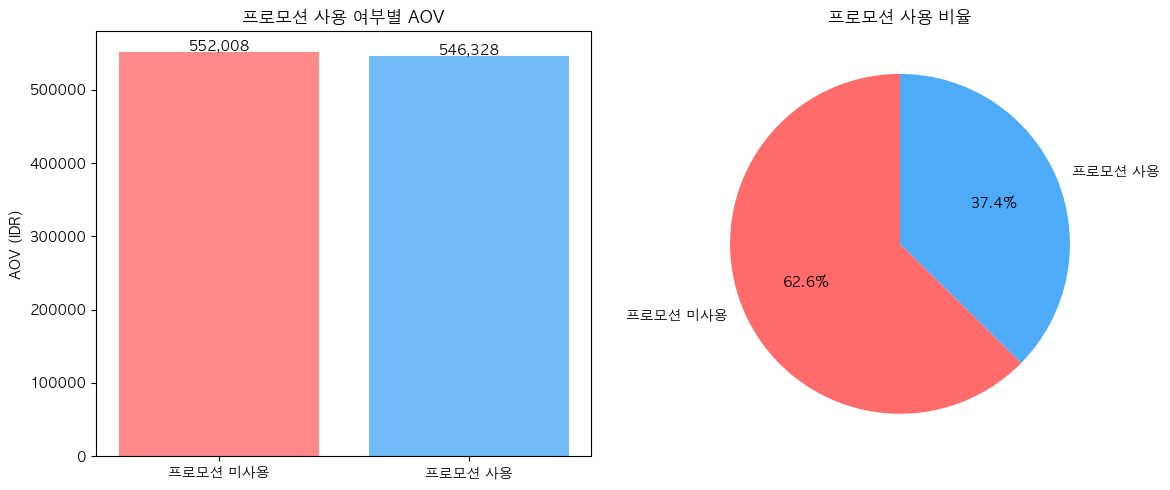

In [299]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 차트 1 - AOV 비교 막대
axes[0].bar(promo_aov['promo_type'],
            promo_aov['aov_mean'],
            color=['#FF6B6B', '#4DABF7'],
            alpha=0.8)
axes[0].set_title('프로모션 사용 여부별 AOV')
axes[0].set_ylabel('AOV (IDR)')
for i, v in enumerate(promo_aov['aov_mean']):
    axes[0].text(i, v + 1000, f'{v:,.0f}', 
                 ha='center', fontsize=10)

# 차트 2 - 거래건수 비율 파이
axes[1].pie(promo_aov['order_count'],
            labels=promo_aov['promo_type'],
            autopct='%1.1f%%',
            colors=['#FF6B6B', '#4DABF7'],
            startangle=90)
axes[1].set_title('프로모션 사용 비율')

plt.tight_layout()
plt.show()

In [300]:
# 월별 프로모션 사용 비율
monthly_promo = transactions.groupby('year_month').agg(
    order_count=('created_at', 'count'),
    promo_count=('promo_used', 'sum'),
    aov_mean=('total_amount', 'mean')
).reset_index()

monthly_promo['promo_ratio'] = (
    monthly_promo['promo_count'] / monthly_promo['order_count'] * 100
).round(2)

print(monthly_promo[['year_month', 'order_count', 'promo_count', 'promo_ratio', 'aov_mean']])

   year_month  order_count  promo_count  promo_ratio  aov_mean
0     2019-01         8067         3552           44    551781
1     2019-02         7539         3306           44    540965
2     2019-03         8800         3884           44    528697
3     2019-04         8683         3753           43    542526
4     2019-05         9320         4160           45    554379
5     2019-06         9025         4116           46    553121
6     2019-07        10440         4687           45    545813
7     2019-08        10459         4571           44    552502
8     2019-09        10546         4658           44    556733
9     2019-10        11006         4874           44    542564
10    2019-11        11347         5001           44    543598
11    2019-12        11562         5229           45    531630
12    2020-01        11941         5260           44    543649
13    2020-02        11742         5079           43    554191
14    2020-03        12916         5480           42   

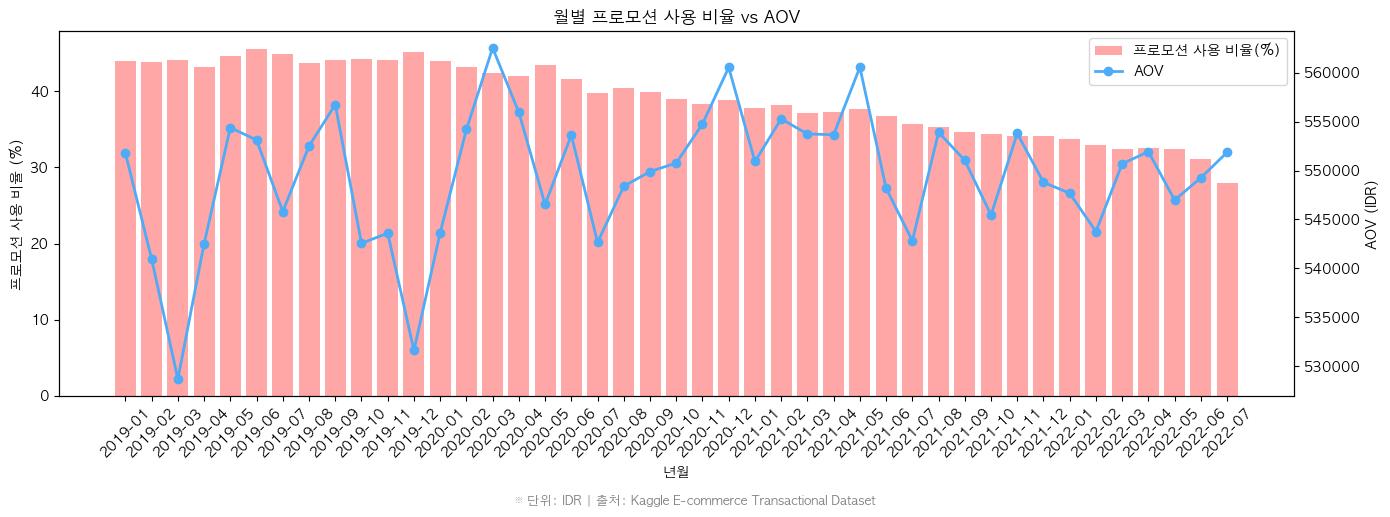

In [301]:
fig, ax1 = plt.subplots(figsize=(14, 5))

x = range(len(monthly_promo))

# 프로모션 사용 비율 막대
ax1.bar(x, monthly_promo['promo_ratio'],
        color='#FF6B6B', alpha=0.6, label='프로모션 사용 비율(%)')
ax1.set_ylabel('프로모션 사용 비율 (%)')
ax1.set_xlabel('년월')
ax1.set_xticks(list(x))
ax1.set_xticklabels(monthly_promo['year_month'].astype(str), rotation=45)

# AOV 라인 (보조축)
ax2 = ax1.twinx()
ax2.plot(x, monthly_promo['aov_mean'],
         color='#4DABF7', marker='o', linewidth=2, label='AOV')
ax2.set_ylabel('AOV (IDR)')

# 범례 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('월별 프로모션 사용 비율 vs AOV')
fig.text(0.5, -0.02,
         '※ 단위: IDR | 출처: Kaggle E-commerce Transactional Dataset',
         ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

1. 프로모션 사용 시 실제로 AOV가 낮아지는가?  
>    - 차이가 거의 없다 (5,680 IDR 약 1%)
  
2. 프로모션 의존도가 시간이 갈수록 높아지고 있는가?  
>    - 2019년 44% → 2022년 28%  
>    - 오히려 감소 추세


#### ⇒ 프로모션이 AOV에 영향이 없다.

#### ▸ 그럼, 프로모션의 진짜 역할은 무엇인가?
1. CVR을 올리는가? 

In [302]:
# click_stream에서 퍼널 구성
# event_name 종류 먼저 확인
print(click_stream['event_name'].value_counts())
click_stream.head()

event_name
CLICK          2176750
HOMEPAGE       2158372
ADD_TO_CART    1647320
SCROLL         1453921
ITEM_DETAIL    1126164
SEARCH         1026648
BOOKING         740511
PROMO_PAGE      521107
ADD_PROMO       275592
Name: count, dtype: int64


,session_id,event_name,event_time,event_id,traffic_source,event_metadata
0,fb0abf9e-fd1a-44dd-b5c0-2834d5a4b81c,HOMEPAGE,2019-09-06 15:54:32.821085+00:00,9c4388c4-c95b-4678-b5ca-e9cbc0734109,MOBILE,NaN
1,fb0abf9e-fd1a-44dd-b5c0-2834d5a4b81c,SCROLL,2019-09-06 16:03:57.821085+00:00,4690e1f5-3f99-42d3-84a5-22c4c4d8500a,MOBILE,NaN
2,7d440441-e67a-4d36-b324-80ffd636d166,HOMEPAGE,2019-09-01 12:05:10.322763+00:00,88aeaeb5-ec98-4859-852c-8abb483faf31,MOBILE,NaN
3,7d440441-e67a-4d36-b324-80ffd636d166,ADD_TO_CART,2019-09-01 12:06:33.322763+00:00,934e306e-ecc6-472f-9ccb-12c8536910a2,MOBILE,"{'product_id': 15315, 'quantity': 4, 'item_pri..."
4,7d440441-e67a-4d36-b324-80ffd636d166,BOOKING,2019-09-01 12:15:29.425431+00:00,9f4767a1-40fa-4c9c-9524-dfad18634d56,MOBILE,{'payment_status': 'Success'}


In [303]:
import ast

# event_metadata에서 payment_status 추출
def get_payment_status(metadata):
    try:
        if pd.isna(metadata):
            return None
        data = ast.literal_eval(metadata)
        return data.get('payment_status', None)
    except:
        return None
click_stream['payment_status'] = click_stream['event_metadata'].apply(get_payment_status)

# 세션별 이벤트 + 결제 성공 여부
session_funnel = click_stream.groupby('session_id').apply(
    lambda x: pd.Series({
        'used_promo': 'ADD_PROMO' in x['event_name'].values,
        'purchased': (
            (x['event_name'] == 'BOOKING') & 
            (x['payment_status'] == 'Success')
        ).any()
    })
).reset_index()

# CVR 계산
cvr_by_promo = session_funnel.groupby('used_promo').agg(
    total_session=('session_id', 'count'),
    purchased=('purchased', 'sum')
).reset_index()

cvr_by_promo['cvr'] = (
    cvr_by_promo['purchased'] / cvr_by_promo['total_session'] * 100
).round(2)

cvr_by_promo['promo_type'] = cvr_by_promo['used_promo'].map(
    {True: '프로모션 사용', False: '프로모션 미사용'}
)

print(cvr_by_promo[['promo_type', 'total_session', 'purchased', 'cvr']])

  promo_type  total_session  purchased  cvr
0   프로모션 미사용         496203     444875   90
1    프로모션 사용         275592     263812   96


1. CVR을 올리는가? 
>    - 차이 : 약 6% 
>    - 프로모션 사용시 CVR 증가

#### 프로모션의 역할
>    - 구매 망설이는 고객을 전환시키는 역할
>    - 단가를 높이는 역할은 못함


### 가설 B 결론
**"프로모션 의존도가 높아져 AOV가 희석되는가?"**

#### 분석 결과

1. 프로모션 사용 여부별 AOV
   - 미사용 552,008 / 사용 546,328
   - 차이 약 1% → 유의미한 차이 X 

2. 프로모션 사용 비율 월별 추이
   - 2019년 44% → 2022년 28%
   - 오히려 감소 추세

3. 프로모션 사용 여부별 CVR
   - 미사용 89.66% / 사용 95.73%
   - 프로모션 사용 시 CVR 약 6%p 높음

#### 종합 : 가설 B 기각
>   1. 프로모션이 AOV에는 영향 없음.  
>   2. 프로모션 의존도도 높아지지 않음.  
>   3. 프로모션은 CVR을 올리는 역할만 함.  
>   4. 고가 세그먼트 이탈 확인 필요. (가설 C)


### C. 고가 상품 구매 비율 감소하고 있는가? 
>       두 가설이 기각되면서 새로운 관점 필요  
>       → 매출은 오르고 거래건수도 오르는데 AOV는 정체  
>       → 고가 상품을 구매하던 고객층이 이탈하고 있는 것 아닐까?  
>       → 고가 구매 비율이 줄면 거래건수가 늘어도 AOV는 정체될 수 있음  

#### ⇒ 고가 상품 구매 비율이 감소하고 있는가?
#### ⇒ 어떤 카테고리가 고가 구매를 이끄는가?

In [360]:
# 고가 상품 확인을 위한 상품 단가 확인
print(product.info())

<class 'pandas.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  str    
 2   masterCategory      44424 non-null  str    
 3   subCategory         44424 non-null  str    
 4   articleType         44424 non-null  str    
 5   baseColour          44409 non-null  str    
 6   season              44403 non-null  str    
 7   year                44423 non-null  float64
 8   usage               44107 non-null  str    
 9   productDisplayName  44417 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 3.4 MB
None


#### product 테이블에 단가 컬럼 없음
####  **transactions에서 단가 역산 시도**


In [398]:
# transactions['metadata_parsed'] 파싱
import ast

def parse_metadata(metadata):
    try:
        return ast.literal_eval(metadata)
    except:
        return []

transactions['metadata_parsed'] = transactions['product_metadata'].apply(parse_metadata)


# 상품별로 행 펼치기 (explode)
transactions_exploded = transactions.explode('metadata_parsed')

# product_id, item_price, quantity 추출
transactions_exploded['product_id'] = transactions_exploded['metadata_parsed'].apply(
    lambda x: x.get('product_id', None) if isinstance(x, dict) else None
)
transactions_exploded['item_price'] = transactions_exploded['metadata_parsed'].apply(
    lambda x: x.get('item_price', None) if isinstance(x, dict) else None
)
transactions_exploded['quantity'] = transactions_exploded['metadata_parsed'].apply(
    lambda x: x.get('quantity', None) if isinstance(x, dict) else None
)

print(transactions_exploded[['booking_id', 'product_id', 'item_price', 'quantity']].head(10))
print(f"원본 행수: {len(transactions)}")
print(f"explode 후 행수: {len(transactions_exploded)}")

                             booking_id  product_id  item_price  quantity
0  790bca1f-d76c-4641-bc7e-7674323ea579       26182      131827         1
1  c6f1e5df-bd15-4e0e-be0a-a9e2a5cb3b82       46931      343876         3
2  249aa61e-5fee-4686-99ef-fbc5a17ddb4b       21623      232447         1
3  2a411748-9ce2-4092-810c-5b1e8ea811b8       46060      263017         2
4  fc8fd52a-cd88-4377-b691-4beb9ef7c24b       44762      583463         1
5  77ca06d5-a6ca-4132-85e4-21fff8551fa7       30196      355026         1
6  3cd25521-e6d4-44d8-9cb7-3b3aa7de14cc       49521      169630         1
7  a3811c17-7652-4c97-a2b2-3bec36943e9a       42834      302111         1
7  a3811c17-7652-4c97-a2b2-3bec36943e9a       25364      474178         1
8  1aa772e2-5ba8-4ca0-9af0-ea320b8f505d       39981      101528         1
원본 행수: 740513
explode 후 행수: 1089586


In [400]:
# 실제 단가 계산
transactions_exploded['unit_price'] = (
    transactions_exploded['item_price'] / transactions_exploded['quantity']
)
#print(transactions_exploded[['product_id', 'quantity', 'item_price', 'unit_price']].head(10))

product_unit_price = product.merge(
    transactions_exploded[['product_id', 'unit_price', 'year_month']],
    left_on = 'id',
    right_on = 'product_id',
    how='left'
)

#print(product_unit_price.sort_values(['product_id','year_month'], ascending=True).head(30))
print(product_unit_price[product_unit_price['product_id']==1163].sort_values(['year_month'], ascending=True))
#print(transactions_exploded[['year_month', 'created_at', 'product_id', 'item_price', 'quantity', 'unit_price']].sort_values(['product_id','year_month'], ascending=True).head(20))

          id gender masterCategory subCategory articleType baseColour  season  \
316745  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316746  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316747  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316748  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316749  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316750  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316751  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316752  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316753  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316754  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316755  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316757  1163    Men        A

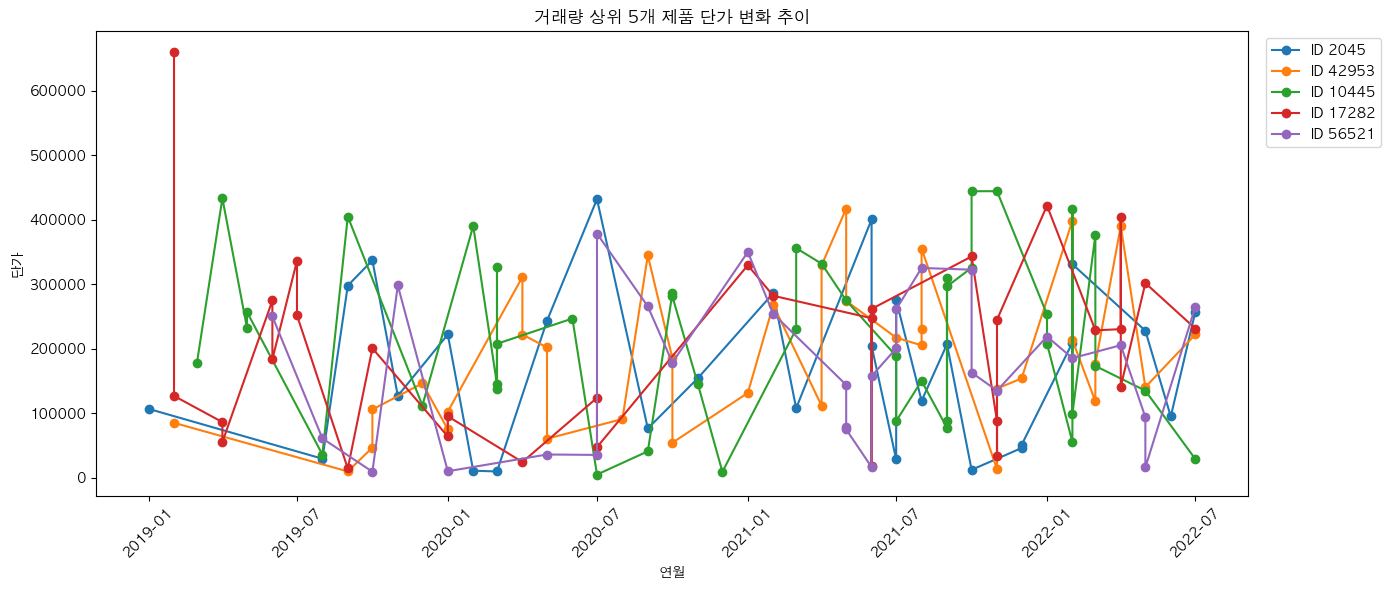

In [401]:
# 거래량 상위 5개 제품
top5_product = (
    transactions_exploded.groupby('product_id')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# 필터링
price_top5 = product_unit_price[product_unit_price['product_id'].isin(top5_product)]

fig, ax = plt.subplots(figsize=(14, 6))

for pid in top5_product:
    data = price_top5[price_top5['product_id'] == pid].sort_values('year_month')
    x = data['year_month'].dt.to_timestamp()
    ax.plot(x, data['unit_price'], marker='o', label=f'ID {int(pid)}', linewidth=1.5)

ax.set_title('거래량 상위 5개 제품 단가 변화 추이')
ax.set_xlabel('연월')
ax.set_ylabel('단가')
ax.tick_params(axis='x', rotation=45)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### 데이터 검증 과정에서 발견한 데이터 구조
- tansactions의 거래마다 동일 상품의 단가가 일정하지 않고 들쭉날쭊함.
- 예시) product_id 2045 : 10,059 - 431,914 IDR로 들쭉날쭉
- 상품 단가로 고가 세그먼트 기준 정의 불가
#### ⇒ 상품별 평균 단가로 고가 세그먼트 기준 정의

In [409]:
# 상품별 평균 단가
product_avg_price = product_unit_price.groupby('product_id').agg(
    avg_unit_price=('unit_price', 'mean')
).reset_index()

#print(product_avg_price.sort_values(['avg_unit_price'], ascending=False))

# 고가 기준 = 상위 25%
q75 = product_avg_price['avg_unit_price'].quantile(0.75)
product_avg_price['is_premium'] = (
    product_avg_price['avg_unit_price'] >= q75
)

print(f"고가 기준: {q75:,.0f} IDR 이상")
print(product_avg_price['is_premium'].value_counts())

# transactions_exploded에 is_premium 붙이기
transactions_priemium = transactions_exploded.merge(
    product_avg_price[['product_id', 'is_premium']],
    on='product_id',
    how='left'
)

# 월별 고가 구매 비율
monthly_premium = transactions_priemium.groupby('year_month').agg(
    total=('booking_id', 'count'),
    premium=('is_premium', 'sum')
).reset_index()

monthly_premium['premium_ratio'] = (
    monthly_premium['premium'] / monthly_premium['total'] * 100
).round(2)

#print(monthly_premium)

고가 기준: 238,570 IDR 이상
is_premium
False    33318
True     11106
Name: count, dtype: int64


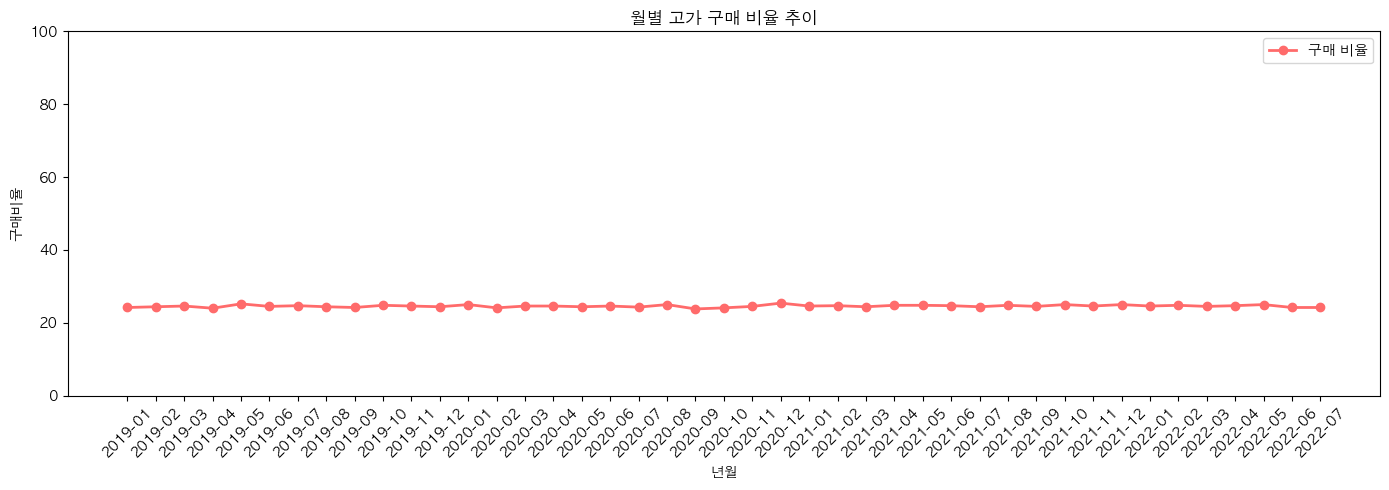

In [410]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(range(len(monthly_premium)),
        monthly_premium['premium_ratio'].round(1),
        marker='o', linewidth=2,
        color='#FF6B6B', label='구매 비율')


ax.set_title('월별 고가 구매 비율 추이')
ax.set_ylabel('구매비율')
ax.set_xlabel('년월')
ax.set_xticks(range(len(monthly_premium)))
ax.set_xticklabels(monthly_premium['year_month'].astype(str), rotation=45)
ax.set_ylim(0, 100) 
ax.legend()


plt.tight_layout()
plt.show()

In [414]:
# transactions_priemium에 카테고리 붙이기
transactions_premium_Category = transactions_priemium.merge(
    product[['id', 'masterCategory', 'subCategory']],
    left_on='product_id',
    right_on='id',
    how='left'
)

# masterCategory 기준으로 고가 구매 비율
category_premium = transactions_premium_Category.groupby('masterCategory').agg(
    total=('booking_id', 'count'),
    premium=('is_premium', 'sum')
).reset_index()

category_premium['premium_ratio'] = (
    category_premium['premium'] / category_premium['total'] * 100
).round(2)

category_premium = category_premium.sort_values(
    'premium_ratio', ascending=False)

print(category_premium)

   masterCategory   total premium premium_ratio
6  Sporting Goods     589     171            29
2        Footwear  226414   56409            25
1         Apparel  524924  129796            25
0     Accessories  275586   67449            24
5   Personal Care   58914   13658            23
3      Free Items    2592     514            20
4            Home      18       0             0


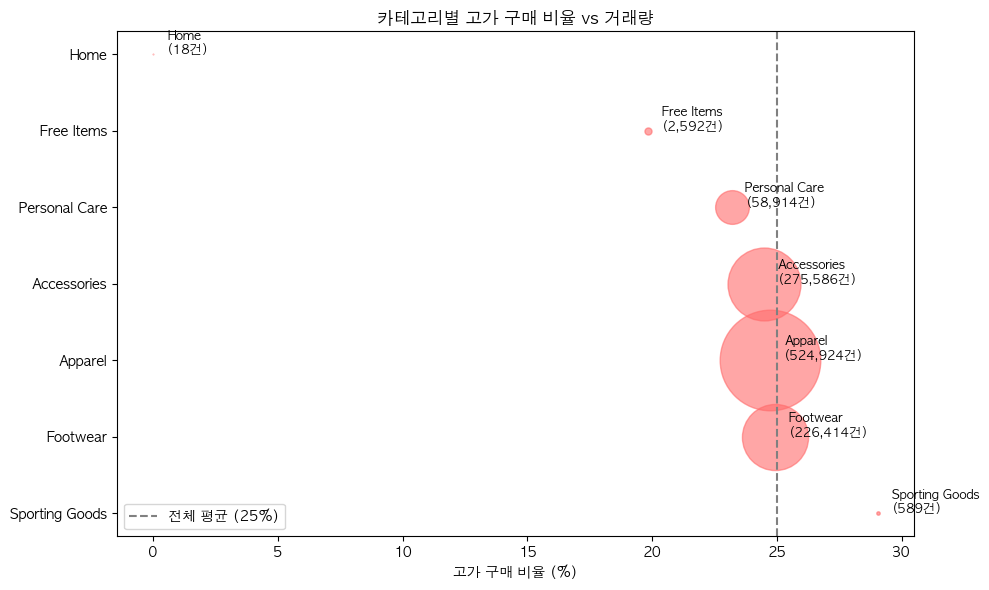

In [442]:
fig, ax = plt.subplots(figsize=(10, 6))

for _, row in category_premium.iterrows():
    ax.scatter(row['premium_ratio'], 
               row['masterCategory'],
               s=row['total']/100,  # 버블 크기 = 거래량
               alpha=0.6,
               color='#FF6B6B')
    ax.annotate(f"{row['masterCategory']}\n({row['total']:,}건)",
                (row['premium_ratio'], row['masterCategory']),
                textcoords='offset points',
                xytext=(10, 0), fontsize=9)

ax.axvline(x=25, color='gray', linestyle='--', label='전체 평균 (25%)')
ax.set_title('카테고리별 고가 구매 비율 vs 거래량')
ax.set_xlabel('고가 구매 비율 (%)')
ax.legend()

plt.tight_layout()
plt.show()

1. 고가 상품 구매 비율이 감소하고 있는가? 
>    - 25% 일정하게 나타남
  
2. 어떤 카테고리가 고가 구매를 이끄는가?
>    - 주력 카테고리 (Apparel/Footwear/Accessories) : 모두 25% 내외로 균일
>    - Sporting Goods만 29%지만  
>      거래량 589건으로 전체의 0.05%

#### ⇒ 고가 상품 구매비율 일정하고 특정 카테고리가 고가 구매를 이끄는 구조 아님.

### 가설 C 결론
**"고가 상품 구매 비율 감소하고 있는가?"**

#### 분석 결과

1. 상품별 평균 단가 기준 고가 정의
   - 데이터 검증 과정에서 같은 상품도 거래마다 단가가 다름
   - 상품 단가로 고가 세그먼트 기준 정의 불가
   - 상품별 평균 단가로 상위 25% 기준 고가 세그먼트 기준 정의

2. 월별 고가 구매 비율 추이
   - 기간 내 구매 비율도 약 25% 수준으로 일정

3. 카테고리별 고가 상품 구매 비율 비교
   - 주력 카테고리가 25% 내외로 분포
   - 29%인 카테고리가 있었지만 거래건수가 현저히 낮음

#### 종합 : 가설 C 기각
>   1. 고가 세그먼트 구매 이탈이 없음.  
>   2. 카테고리별 고가 세그먼트 구매비율 균일.  
>   3. 고가 세그먼트는 AOV에 영향을 주지 않음.  


### ▸ 3가지 가설 모두 AOV 정체 설명 불가
### ⇒ AOV 자체에 이상 구간 확인 필요.

## 3. 이상구간 분석
-----

###  이상구간 분석 목적
- 3가지 가설 모두 기각
- 단일 원인으로 AOV 정체 설명 불가
- 거래건수는 증가하는데 AOV가 오르지 않는 구간이 있는가?

### 이상구간 정의하기 
- 시계열 데이터 특성 반영
- 3개월 이동평균 기준으로 트렌드 반영
- **거래건수가 이동평균 대비 증가했음에도**  
  **AOV가 이동평균 - 1.5 표준편차 이하로 떨어진 구간**

#### ⇒ 거래건수 증가 + AOV 증가 하지 않는 구간 특정


In [ ]:
#monthly_stats = monthly_stats.drop(columns=['aov_rolling_std', ''])

In [458]:
# 3개월 이동평균
monthly_stats['order_rolling_mean'] = (
    monthly_stats['order_cnt'].rolling(3).mean()
)
monthly_stats['aov_rolling_mean'] = (
    monthly_stats['aov_net'].rolling(3).mean()
)

aov_std = monthly_stats['aov_net'].std()

# 이상구간 = 이동평균 대비 전체 std 1.5배 벗어난 구간
monthly_stats['aov_std_upper'] = monthly_stats['aov_rolling_mean'] + 1.5 * aov_std
monthly_stats['aov_std_lower'] = monthly_stats['aov_rolling_mean'] - 1.5 * aov_std


print(monthly_stats.head(10))

# 이상구간 정의
# 거래건수 증가 + AOV 이동평균 - 1.5 표준편차 이하
monthly_stats['is_anomaly'] = (
    (monthly_stats['order_cnt'] > monthly_stats['order_rolling_mean']) &
    ((monthly_stats['aov_net'] < monthly_stats['aov_std_lower']) | (monthly_stats['aov_net'] > monthly_stats['aov_std_upper']))
)

# 각 조건 따로 확인
print("거래건수 이동평균 초과 개월수:")
print((monthly_stats['order_cnt'] > 
       monthly_stats['order_rolling_mean']).sum())

print("\nAOV 1.5σ 이하 개월수:")

print(monthly_stats['is_anomaly'].value_counts())

anomaly_months = monthly_stats[monthly_stats['is_anomaly'] == True]
print(anomaly_months[['year_month', 'order_cnt', 'aov_net']])


  year_month  order_cnt  gross_revenue  net_revenue    aov  aov_net  \
0    2019-01       8067     4451220191   4377360191 551781   542626   
1    2019-02       7539     4078335557   4009220557 540965   531797   
2    2019-03       8800     4652533315   4572898315 528697   519648   
3    2019-04       8683     4710749035   4630714035 542526   533308   
4    2019-05       9320     5166810538   5081435538 554379   545218   
5    2019-06       9025     4991920475   4910560475 553121   544106   
6    2019-07      10440     5698289321   5602804321 545813   536667   
7    2019-08      10459     5778618243   5681718243 552502   543237   
8    2019-09      10546     5871310137   5774800137 556733   547582   
9    2019-10      11006     5971461341   5869641341 542564   533313   

   is_anomaly  order_rolling_mean  aov_rolling_mean  aov_rolling_std  \
0       False                 NaN               NaN              NaN   
1       False                 NaN               NaN              NaN   
2 

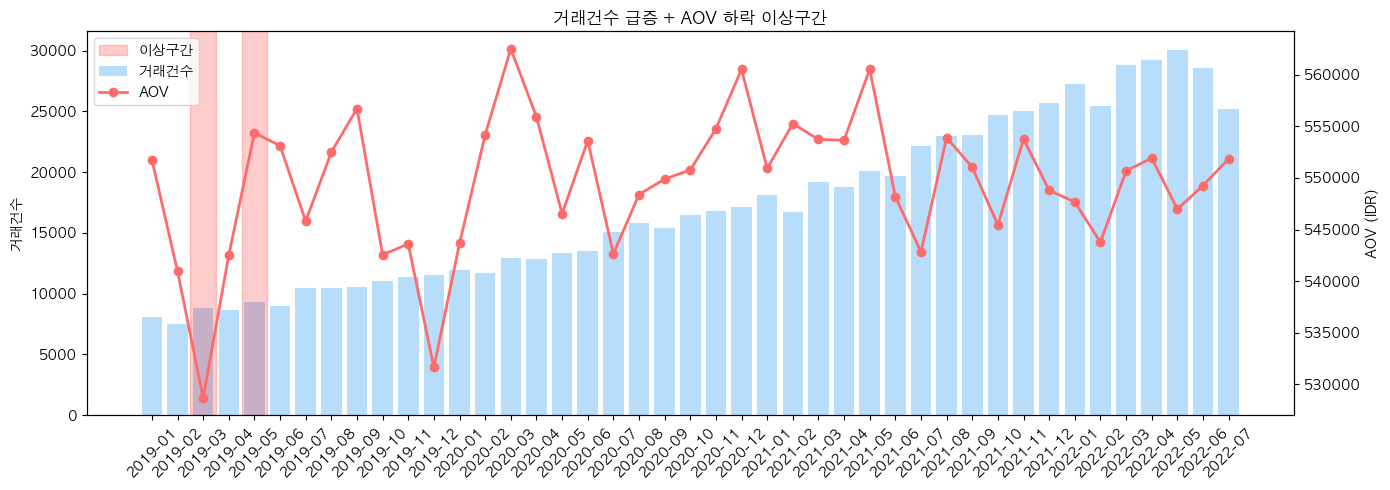

In [459]:
fig, ax1 = plt.subplots(figsize=(14, 5))

x = range(len(monthly_stats))

# 거래건수 막대
ax1.bar(x, monthly_stats['order_cnt'],
        color='#4DABF7', alpha=0.4, label='거래건수')
ax1.set_ylabel('거래건수')

# AOV 라인 (보조축)
ax2 = ax1.twinx()
ax2.plot(x, monthly_stats['aov'],
         color='#FF6B6B', marker='o',
         linewidth=2, label='AOV')
ax2.set_ylabel('AOV (IDR)')

# 이상구간 표시
for idx, row in monthly_stats[monthly_stats['is_anomaly']].iterrows():
    ax1.axvspan(idx-0.5, idx+0.5,
                alpha=0.2, color='red',
                label='이상구간' if idx == monthly_stats[monthly_stats['is_anomaly']].index[0] else '')

ax1.set_xticks(list(x))
ax1.set_xticklabels(monthly_stats['year_month'].astype(str), rotation=45)
ax1.set_title('거래건수 급증 + AOV 하락 이상구간')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

### 이상구간 분석 결과
- AOV 이상구간 2개 발견 (2019-03, 2019-05)
- 서비스 초기 구간 (거래건수 8,000~9,000건)
- 2020년 이후 이상구간 없음 (AOV 변동성 감소)

#### 종합
> - **AOV가 특정 시점이 아닌 전 기간에 걸쳐 균일하게 유지됨**  

### ▸ AOV 정체는 특정 이벤트/시점의 구간 문제가 아님
### ⇒ 퍼널 분석으로 구매 전환 과정 자체를 살펴볼 필요 있음


## 4. 퍼널 분석
-----

###  퍼널 분석 목적
- 3가지 가설 모두 기각
- AOV 정체가 특정 시점의 문제가 아님을 확인
- **거래건수는 늘고 있는데 AOV는 오르지 않는다**
  - 거래는 늘고 있는데 주문당 금액은 그대로
  - 구매 전환 과정에서 무언가 AOV를 제한하고 있는 것 아닐까?
  - 어느 단계에서 이탈이 발생하는가?

#### ⇒ 전체 퍼널 이탈율 확인
#### ⇒ traffic_source별 퍼널 비교